# Caregiver Survey Response Review

This notebook starts with real responses and plain explanations, then shows only the charts that change a payment decision. Summaries that work better as exact counts stay as tables.

1. **What the screen looks for in the actual survey sections**
2. **Where the timing lines came from in the verified caregiver sample**
3. **What showed up in the online recruitment sample**
4. **Which patterns are doing most of the holding**

In [1]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

import bot_analysis as ba

ba = importlib.reload(ba)

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 90)

project_dir = Path.cwd()
output_dir = project_dir / "Caregiver Outputs"
cache_dir = project_dir / "data_cache"

# Reader-facing tables and charts built from the saved study outputs.
views = ba.build_notebook_views(output_dir, cache_dir)
report_records = views["report_records"]
action_summary = ba.build_workbook_action_summary(report_records)
timing_summary = ba.build_workbook_timing_summary(report_records)
study_action_summary = views["study_action_summary"]
queue_severity_summary = views["flag_strength_summary"]

# One record-level frame behind the timing and decision views below.
screen_inputs = ba.build_screen_inputs(output_dir, cache_dir)

print(f"Loaded {len(report_records):,} responses across both studies")
print(screen_inputs["Group"].value_counts().to_string())

Loaded 1,956 responses across both studies
Group
Online sign-ups           1779
Caregivers we verified     177


## Start here: five real responses

Before the charts, read these examples once.

- **Study 1** is the verified caregiver sample.
- **Study 2** is the online recruitment sample.
- The four survey sections are **Family Information**, **Values**, **Thoughts, Feelings, and Attitudes**, and **Demographics**.
- The later charts keep coming back to the same ideas: unusually short section times, repeated ratings within a block, Family Information mismatches, and bursts of sign-ups arriving together.

In [2]:
display(ba.build_worked_examples(screen_inputs, output_dir=output_dir, cache_dir=cache_dir))

,Response,Family Information,"Thoughts, Feelings, and Attitudes",Timing and arrival,Why this response landed here,Decision
0,1779,2 children; 0 autistic children; pregnancy item marked no; Family Information answers ...,"Example item ratings: happy=4, scared=3, difficult=4, doable=1; answers moved across t...",Whole survey 35m 32s; Thoughts/Feelings/Attitudes 28m 24s,"Nothing in the timings or answer pattern stood out, so this response stays in the pay-...",Cleared for payment now
1,1243,1 child; 1 autistic child; pregnancy item marked no; Family Information answers lined up.,"Example item ratings: happy=3, scared=4, difficult=3, doable=2; answers moved across t...",Whole survey 30m 50s; Thoughts/Feelings/Attitudes 21m 17s; Arrived inside a 1-minute c...,"Only one milder pattern showed up, so this response needs just a quick check before pa...",Low-risk provisional approval
2,1276,1 child; 1 autistic child; pregnancy item marked no; Family Information answers lined up.,"Example item ratings: happy=4, scared=4, difficult=3, doable=2; answers moved across t...",Whole survey 21m 14s; Thoughts/Feelings/Attitudes 16m 17s; Section below the verified-...,"2 milder patterns showed up together, so this response is held for review.",Needs human review
3,1355,2 children; 0 autistic children; pregnancy item marked no; Family Information answers ...,"Example item ratings: happy=5, scared=2, difficult=3, doable=2; answers moved across t...",Whole survey 10m 50s; Thoughts/Feelings/Attitudes 7m 41s; Section below the verified-c...,"2 strong patterns and 2 supporting patterns showed up, so this response is held for re...",Needs human review
4,1026,1 child; 1 autistic child; pregnancy item marked yes; Marked prenatal screening as yes...,"Example item ratings: happy=3, scared=5, difficult=2, doable=2; answers changed very l...",Whole survey 4m 10s; Thoughts/Feelings/Attitudes 2m 28s; Section below the verified-ca...,Very fast timing plus answer-pattern or Family Information problems put this response ...,Confirmed bot / reject


## The payment screen in one line

> **A response is held when it crosses one strong line on its own, or when two milder patterns appear together.**
> **One mild pattern alone means quick check. No unusual pattern means pay now.**

The table below shows where each pattern comes from in the actual questionnaire or sign-up record.

In [3]:
display(ba.build_decision_rule_table())

,What we look for,Where it appears,How seriously we treat it,How it affects payment
0,Whole survey too fast,Whole survey timing,Serious,Any one of these on its own moves the response to review
1,"Thoughts, Feelings, and Attitudes section too fast","Thoughts, Feelings, and Attitudes timing",Serious,Any one of these on its own moves the response to review
2,Answer sheet identical to another response,Full answer pattern across the questionnaire,Serious,Any one of these on its own moves the response to review
3,Family answers contradict each other,Family Information,Serious,Any one of these on its own moves the response to review
4,Age and location cannot both be true,Demographics,Serious,Any one of these on its own moves the response to review
5,One section rushed,"Section timing across Family Information, Values, Thoughts/Feelings/Attitudes, or Demo...",Supporting,Two or more of these together move the response to review
6,Same answer repeated down a block,Repeated ratings within a survey block,Supporting,Two or more of these together move the response to review
7,Arrived within a minute of two or more others,Response arrival time,Supporting,Two or more of these together move the response to review
8,Comment nearly identical to another,Open-text comment,Supporting,Two or more of these together move the response to review


### Where the timing lines came from

The timing lines were not chosen after looking at Study 2. Each one was set from the 131 verified caregivers who finished all four sections in Study 1.

Read the table below as: what part of the survey was timed, what line was used, and which verified-caregiver answers set that line.

In [4]:
display(ba.build_limit_origin_table(output_dir))

,What we check,The line we drew,How that line was worked out,Whose answers set it
0,Whole survey too fast,11 minutes 34 seconds,The fastest verified caregiver who finished every section,The 131 verified caregivers who finished every section
1,"Thoughts, Feelings, and Attitudes section too fast",7 minutes 51 seconds,The fastest verified caregiver on that section,The 131 verified caregivers who finished every section
2,Family information section rushed,47 seconds,The fastest 1 in 100 verified caregivers on that section,The 131 verified caregivers who finished every section
3,Values section rushed,41 seconds,The fastest 1 in 100 verified caregivers on that section,The 131 verified caregivers who finished every section
4,Attitudes section rushed,8 minutes 34 seconds,The fastest 1 in 100 verified caregivers on that section,The 131 verified caregivers who finished every section
5,Demographics section rushed,1 minute 6 seconds,The fastest 1 in 100 verified caregivers on that section,The 131 verified caregivers who finished every section
6,Same answer repeated down a block,Answers varied less than 0.78 on a 1-4 block,The 1 in 100 verified caregivers whose answers varied least,The 131 verified caregivers who finished every section
7,Arrived within a minute of two or more others,3 or more sign-ups inside 60 seconds,The 1 in 100 shortest gaps between verified caregiver sign-ups,The 131 verified caregivers who finished every section


---
## 1. Do the timing lines make sense?

Study 1 is the verified caregiver sample, so it shows how fast a real caregiver has actually moved through the survey. Study 2 is the online recruitment sample that we are screening for payment decisions.

### How to read the timing charts

- **Blue bars** are the verified caregiver sample.
- **Orange bars** are the online recruitment sample.
- The **dashed line** is the fastest verified caregiver on that view.
- Orange bars to the left of that line are responses faster than anyone we verified.

,Group,Responses we could time,Middle time (minutes),Fastest time (minutes),Faster than the line
0,Caregivers we verified - whole survey,131,26.69,11.57,0 of 131
1,Online sign-ups - whole survey,"1,575",20.87,3.80,"283 of 1,575"
2,"Caregivers we verified - Thoughts, Feelings, and Attitudes section",131,18.93,7.85,0 of 131
3,"Online sign-ups - Thoughts, Feelings, and Attitudes section","1,587",12.22,2.05,"447 of 1,587"


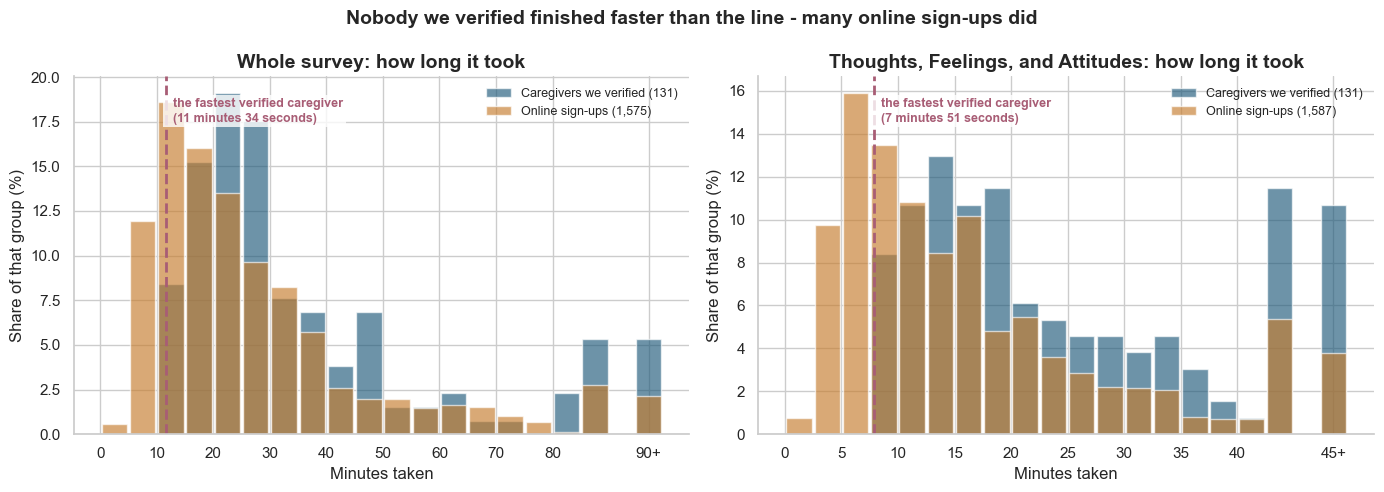

In [5]:
display(ba.build_speed_reference_table(screen_inputs))
ba.plot_speed_comparison(screen_inputs);

### What happens if we move the Thoughts, Feelings, and Attitudes timing line

This is the simplest fairness check. If we loosen the line, we catch more online sign-ups, but we also start catching verified caregivers. The point of the chart is to see where that tradeoff starts.

,Where we draw the line,"Online sign-ups caught (out of 1,587)",Caregivers we know are real caught by mistake (out of 131),What this setting means
0,4 minutes,80,0,"Catches nobody we know is real, but holds fewer sign-ups"
1,5 minutes,167,0,"Catches nobody we know is real, but holds fewer sign-ups"
2,6 minutes,260,0,"Catches nobody we know is real, but holds fewer sign-ups"
3,7 minutes,375,0,"Catches nobody we know is real, but holds fewer sign-ups"
4,7.85 minutes (today's setting),447,0,Today's setting - the last one that catches nobody we know is real
5,9 minutes,543,4,Moves 4 caregiver(s) we know are real into the hold pile
6,10 minutes,633,11,Moves 11 caregiver(s) we know are real into the hold pile
7,12 minutes,774,24,Moves 24 caregiver(s) we know are real into the hold pile
8,15 minutes,939,42,Moves 42 caregiver(s) we know are real into the hold pile


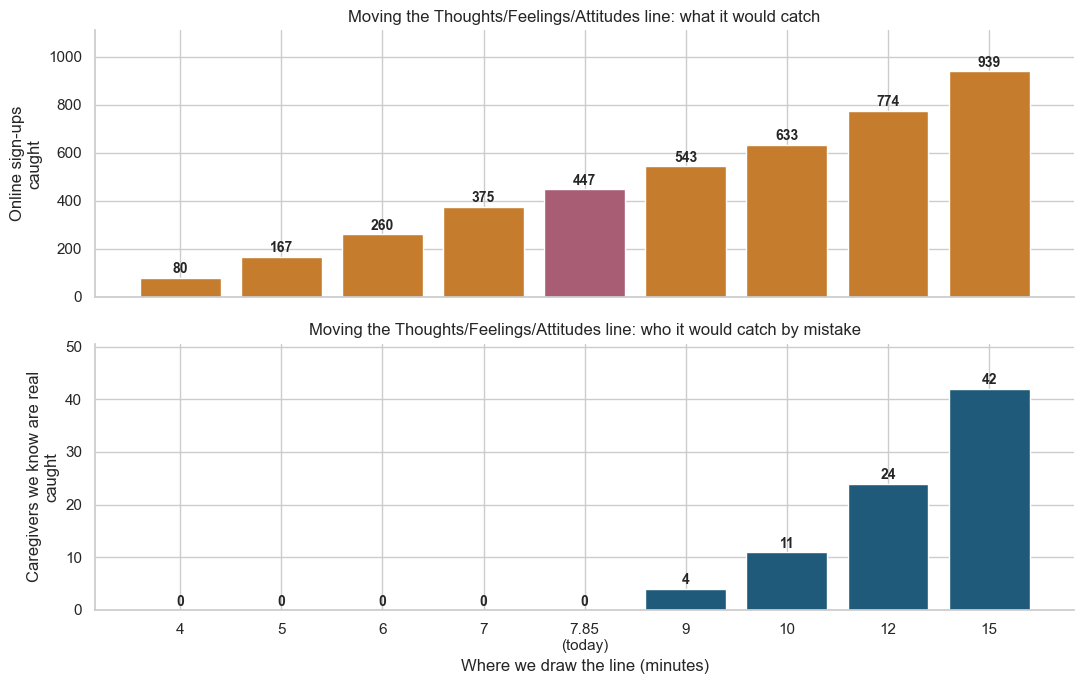

In [6]:
cutoff_sensitivity = ba.build_cutoff_sensitivity_table(screen_inputs)
display(cutoff_sensitivity)
ba.plot_cutoff_sensitivity(cutoff_sensitivity);

### Do these patterns ever show up in the verified caregiver sample?

This table uses the verified sample as a reality check. A pattern that never appears there is reassuring, but with only 131 fully timed verified caregivers it still should not be the only reason to refuse payment.

The row to watch most closely is **Age and location cannot both be true**. In the current data it appears only in the verified sample, not in the online recruitment sample, so it works better as a review cue than as a stand-alone do-not-pay reason.

In [7]:
display(ba.build_wrong_flag_table(screen_inputs))

,Pattern we look for,Where it shows up,How seriously we treat it,Verified caregivers showing this pattern (out of 131),What that tells us,How to use it
0,One section rushed,"Section timing across Family Information, Values, Thoughts/Feelings/Attitudes, or Demo...",Supporting,6,This pattern showed up in 6 of 131 people we know are real.,"Use it to sort the queue, never on its own"
1,Same answer repeated down a block,Repeated ratings within a survey block,Supporting,5,This pattern showed up in 5 of 131 people we know are real.,"Use it to sort the queue, never on its own"
2,Arrived within a minute of two or more others,Response arrival time,Supporting,3,This pattern showed up in 3 of 131 people we know are real.,"Use it to sort the queue, never on its own"
3,Age and location cannot both be true,Demographics,Serious,2,This pattern showed up in 2 of 131 people we know are real.,"Review this pattern - it has never shown up in an online sign-up, only on people we kn..."
4,Whole survey too fast,Whole survey timing,Serious,0,Zero here is partly guaranteed - this line was set at the fastest verified caregiver -...,Strong enough to act on with a quick spot check
5,"Thoughts, Feelings, and Attitudes section too fast","Thoughts, Feelings, and Attitudes timing",Serious,0,Zero here is partly guaranteed - this line was set at the fastest verified caregiver -...,Strong enough to act on with a quick spot check
6,Answer sheet identical to another response,Full answer pattern across the questionnaire,Serious,0,This pattern has not shown up in either study.,Strong enough to act on with a quick spot check
7,Family answers contradict each other,Family Information,Serious,0,This pattern has not shown up in either study.,Strong enough to act on with a quick spot check
8,Comment nearly identical to another,Open-text comment,Supporting,0,This pattern has not shown up in either study.,Strong enough to act on with a quick spot check


---
## 2. How common were these patterns in the online recruitment sample?

The five example responses above are just anchors. The next charts show where those same timing, answer-pattern, and Family Information issues sit in the full sample.

### How many unusual patterns showed up on one response

This stays as a table because the exact counts matter more than another bar chart. The next chart shows which specific patterns are creating those counts.

A response with **zero** patterns looks like 1779. A response with **one** pattern looks like 1243. A response with **two or more** starts to look more like 1276, 1355, or 1026.

In [8]:
display(ba.build_checks_set_off_table(screen_inputs))

,Number of patterns on one response,Caregivers we verified,Caregivers we verified (% of group),Online sign-ups,Online sign-ups (% of group)
0,0,153,86.4,70,3.9
1,1,21,11.9,662,37.2
2,2,3,1.7,411,23.1
3,3,0,0.0,275,15.5
4,4,0,0.0,239,13.4
5,5,0,0.0,114,6.4
6,6,0,0.0,8,0.4


### Which patterns were most common

This chart is about **frequency**, not **strength**. A pattern can show up often and still be most useful as background context rather than as a stand-alone payment decision.

,Pattern,Where it shows up,How seriously we treat it,"Online sign-ups showing it (out of 1,779)",Share of online sign-ups,Verified caregivers showing it (out of 177)
0,Arrived within a minute of two or more others,Response arrival time,Supporting,1676,94.2%,6
1,One section rushed,"Section timing across Family Information, Values, Thoughts/Feelings/Attitudes, or Demo...",Supporting,839,47.2%,7
2,Same answer repeated down a block,Repeated ratings within a survey block,Supporting,577,32.4%,12
3,"Thoughts, Feelings, and Attitudes section too fast","Thoughts, Feelings, and Attitudes timing",Serious,447,25.1%,0
4,Whole survey too fast,Whole survey timing,Serious,283,15.9%,0
5,Family answers contradict each other,Family Information,Serious,44,2.5%,0
6,Comment nearly identical to another,Open-text comment,Supporting,17,1.0%,0
7,Answer sheet identical to another response,Full answer pattern across the questionnaire,Serious,0,0.0%,0
8,Age and location cannot both be true,Demographics,Serious,0,0.0%,2


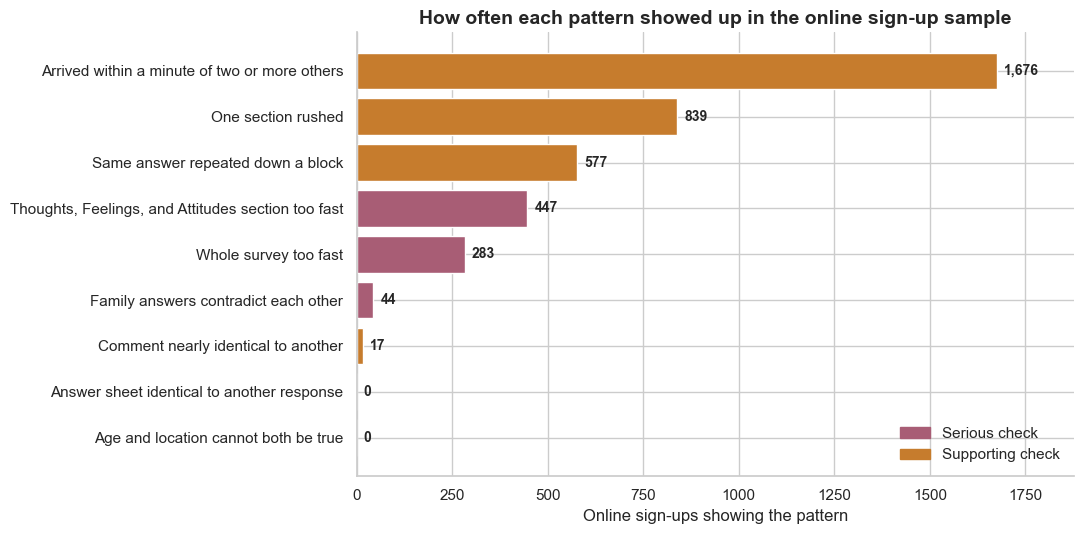

In [9]:
display(ba.build_all_checks_frequency_table(screen_inputs))
ba.plot_all_checks_frequency(screen_inputs);

### When responses came in

This chart compares calendar timing, not questionnaire answers. The two panels use different scales so the verified sample is still visible.

Payment Decision,When it arrived,Responses,Cleared for payment now,Low-risk provisional approval,Needs human review,Confirmed bot / reject
0,The three days before it,57,36,10,11,0
1,Surge day (06 Sep),1722,34,650,1032,6


On 06 Sep 2025, 1,722 of the 1,779 online sign-ups arrived - 1,717 of them inside four hours.
Half of them arrived within 4 seconds of the one before, against about 11 minutes for the verified caregivers.


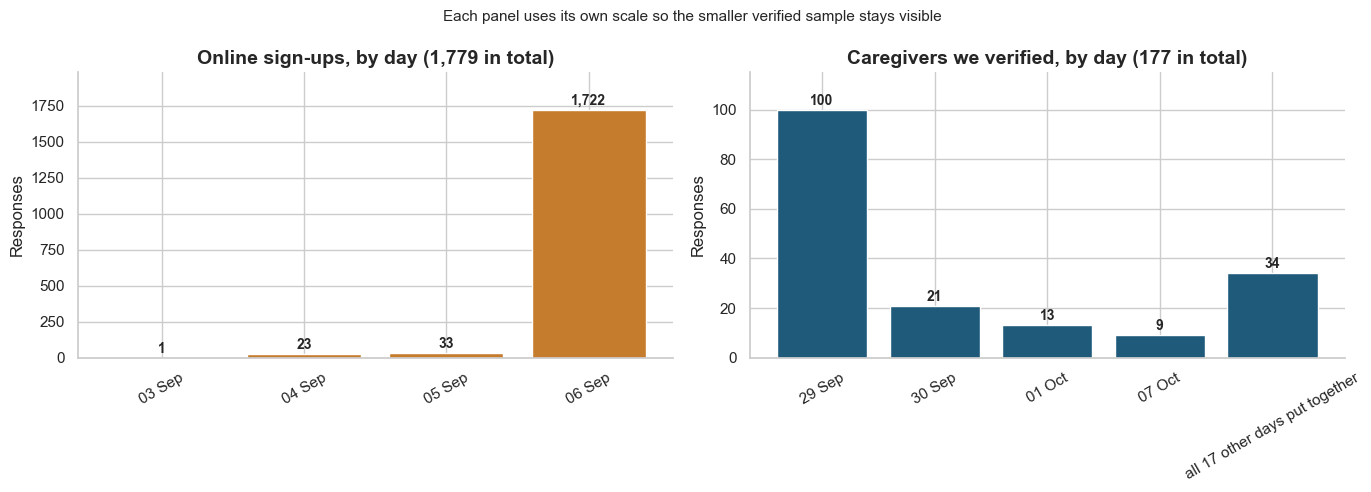

In [10]:
arrival = ba.build_arrival_tables(screen_inputs)
facts = arrival["surge_facts"]

display(arrival["surge_crosstab"])

print(
    f"On {facts['surge_day']:%d %b %Y}, {facts['surge_n']:,} of the {facts['online_n']:,} online "
    f"sign-ups arrived - {facts['busiest_n']:,} of them inside four hours."
)
print(
    f"Half of them arrived within {facts['median_gap_seconds']:.0f} seconds of the one before, "
    f"against about {facts['verified_median_gap_minutes']:.0f} minutes for the verified caregivers."
)
ba.plot_arrival_pattern(screen_inputs);

The three days before the surge contain only 57 responses, so treat them as a small comparison group. Even so, the single surge day produced nearly all of the hold-for-review responses.

---
## 3. How the payment groups break down

These tables show how many responses are in each payment group, how long they usually took, and how the split differs between Study 1 and Study 2.

The study split stays as a table because the group counts are the point. A grouped bar chart does not add new bot-detection evidence here.

In [11]:
display(action_summary)
display(timing_summary)

,Action group,Records,Share of all responses,What to do
0,Pay now,223,11.4%,Send gift card now
1,Low-risk approval,679,34.7%,Approve after quick check
2,Review,1048,53.6%,Hold for human review
3,Do not pay,6,0.3%,Do not pay


,Action group,Study 2 records,Median full survey time,Median attitudes time
0,Pay now,70,35.54 min,23.35 min
1,Low-risk approval,660,30.23 min,19.65 min
2,Review,1043,15.25 min,8.52 min
3,Do not pay,6,9.63 min,4.40 min


The median times above describe the responses inside each payment group. The actual timing lines are still the stricter verified-caregiver lines shown earlier in section 1.

In [12]:
display(study_action_summary)

,Study,Action group,Records,Share within study (%),What to do
0,Study 1 - verified caregiver sample,Pay now,153,86.4,Send gift card now
1,Study 1 - verified caregiver sample,Low-risk approval,19,10.7,Approve after quick check
2,Study 1 - verified caregiver sample,Review,5,2.8,Hold for human review
3,Study 1 - verified caregiver sample,Do not pay,0,0.0,Do not pay
4,Study 2 - online recruitment sample,Pay now,70,3.9,Send gift card now
5,Study 2 - online recruitment sample,Low-risk approval,660,37.1,Approve after quick check
6,Study 2 - online recruitment sample,Review,1043,58.6,Hold for human review
7,Study 2 - online recruitment sample,Do not pay,6,0.3,Do not pay


### How heavy is the hold pile?

Some held responses have only timing or arrival concerns. Others combine timing with Family Information or answer-pattern problems. This table shows that mix.

In [13]:
display(queue_severity_summary)

,Pattern inside the Study 2 hold pile,Records,Share of hold pile (%),How to read it
0,Timing or arrival only,560,53.4,No strong contradiction; these were held because milder timing or arrival patterns pil...
1,One strong questionnaire concern,207,19.7,"One stronger issue is present, but not enough on its own for a do-not-pay decision."
2,Two strong concerns,279,26.6,Two stronger issues show up on the same record; this is the clearest part of the hold ...
3,Three or more strong concerns,3,0.3,Very concentrated concern; this is the strongest end of the hold pile.


---
## 4. What is driving the holds?

The next views strip the decision down to its practical parts: which patterns are doing most of the holding, where timings cannot help at all, and how large the remaining manual review task is.

,Pattern,Where it shows up,How seriously we treat it,Online sign-ups showing it,Times it was the only issue on the response,Responses released if we removed it
0,Arrived within a minute of two or more others,Response arrival time,Supporting,1676,641,400
1,One section rushed,"Section timing across Family Information, Values, Thoughts/Feelings/Attitudes, or Demo...",Supporting,839,6,216
2,Same answer repeated down a block,Repeated ratings within a survey block,Supporting,577,13,189
3,"Thoughts, Feelings, and Attitudes section too fast","Thoughts, Feelings, and Attitudes timing",Serious,447,0,0
4,Whole survey too fast,Whole survey timing,Serious,283,0,1
5,Family answers contradict each other,Family Information,Serious,44,2,9
6,Comment nearly identical to another,Open-text comment,Supporting,17,0,1


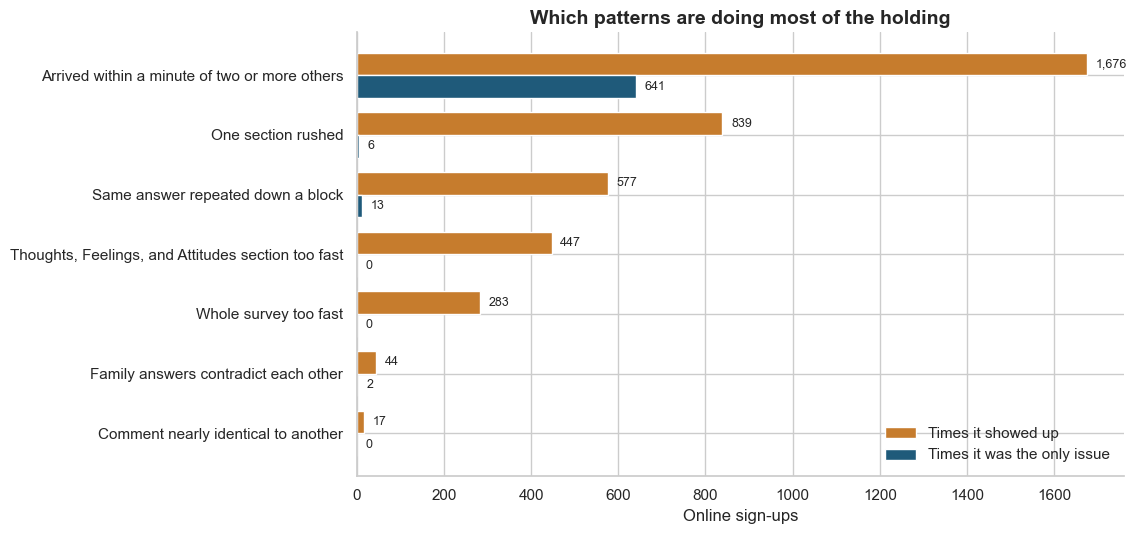

In [14]:
check_impact = ba.build_check_impact_table(screen_inputs)
display(check_impact)
ba.plot_check_impact(check_impact);

The arrival-time cluster is the single biggest driver of holds. Removing it would release many responses, so it is worth confirming that this is really intended as a payment rule and not just background context.

### Where the timing rules cannot help

Every timing view depends on a recorded time. A blank or half-started form can pass beneath the timing screen unless another mismatch shows up.

In [15]:
display(ba.build_timing_coverage_table(screen_inputs))

,What we were able to time,Responses,Approved to pay,Held for review or rejected
0,All four sections timed,1575,574,1001
1,"Some sections timed, attitudes section missing",81,40,41
2,"Some sections timed, one other section missing",12,5,7
3,No timing at all,111,111,0


The bottom row matters: 111 responses cleared the sign-up screen and then left the survey blank. No timing-based rule can reach them because there is no timed questionnaire section to compare.

### Where to start, and what it costs

This table works the hold pile from strongest concern to weakest concern using the current 8-minute planning assumption.

In [16]:
display(ba.build_work_plan_table(screen_inputs, minutes_per_response=8))

,"Batch, worst first",Responses in this batch,Responses checked once this batch is done,"Responses that beat the fastest verified caregiver, found so far",Hours of staff time at 8 minutes each,Responses still unchecked
0,Set off 5 or 6 checks,117,117,117 of 445,16,926
1,Set off 4 checks,238,355,353 of 445,47,688
2,Set off 3 checks,275,630,444 of 445,84,413
3,Set off 2 checks or fewer,413,1043,445 of 445,139,0


Working the most concerning part of the hold pile first reaches almost every response that finished faster than the verified sample. The remaining responses are not cleared; they simply need a different kind of review.

---
## Excel export

This rebuilds the simple workbook from the same tables used above so the notebook and spreadsheet stay aligned.

In [17]:
report_workbook = ba.export_simple_excel(
    output_dir=output_dir,
    cache_dir=cache_dir,
    excel_filename="ESD_Bot_Analysis_Simple_Summary.xlsx",
)
print(f"Workbook written: {report_workbook.name}")
print(pd.ExcelFile(report_workbook).sheet_names)

Workbook written: ESD_Bot_Analysis_Simple_Summary.xlsx
['Summary', 'Pay Now', 'Review Queue', 'Screen Guide', 'Extra Views']


---
## What the numbers say

**The timing lines are defensible.** They were set from the verified caregiver sample, and the online recruitment sample contains many more responses below those lines.

**The clearest warning signs are very fast timing, burst arrival, and occasional Family Information mismatches.** Response 1355 shows timing alone pushing a response into review. Response 1026 shows how timing plus a Family Information contradiction and low-variation ratings produce the strongest concern.

**The biggest practical gap is incomplete forms.** Some responses were approved to pay without any timed survey section at all, so a completion rule is still needed before payments are sent.

**The biggest operational choice is how much weight to give burst arrival.** It is the most common pattern in Study 2 and it moves many responses into the hold pile, but it is mostly useful when read alongside the questionnaire itself.

**Two visuals were intentionally left out.** The study-split grouped bar and the per-response count bar were dropped because their exact counts are easier to read in tables and they did not add new evidence beyond the charts kept here.